In [1]:
#Installing dependencies
!pip install -q kaggle
!pip install -q transformers librosa soundfile scikit-learn tqdm joblib
!pip install -q openai-whisper
!pip install -q faster-whisper
!pip install -q ctranslate2
!pip install -q langdetect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 47.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 47.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


**Connecting to google drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Defining main folder and subpaths of the project**


In [14]:
import os
PROJECT_ROOT = "/content/drive/MyDrive/STUTTERING_WHISPER"

In [15]:
DATA = os.path.join(PROJECT_ROOT, "DATASET")
UCLASS = os.path.join(DATA, "UCLASS")
NNCES = os.path.join(DATA, "NNCES")
AUG = os.path.join(DATA, "AUGMENTED", "AUDIO")

# Metadata and intermediate outputs
METADATA_DIR = os.path.join(PROJECT_ROOT, "METADATA")
WHISPER_DIR = os.path.join(PROJECT_ROOT, "OUTPUTS", "WHISPER_SEGMENTS")
FEATURE_DIR = os.path.join(PROJECT_ROOT, "OUTPUTS", "FEATURES")
MODELS_DIR = os.path.join(PROJECT_ROOT, "MODELS")


# Ensure directories exist (if not, create one)
for d in [DATA, UCLASS, NNCES, AUG, METADATA_DIR, WHISPER_DIR, FEATURE_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("UCLASS path:", UCLASS)
print("NNCES path:", NNCES)
print("FEATURE_DIR:", FEATURE_DIR)

PROJECT_ROOT: /content/drive/MyDrive/STUTTERING_WHISPER
UCLASS path: /content/drive/MyDrive/STUTTERING_WHISPER/DATASET/UCLASS
NNCES path: /content/drive/MyDrive/STUTTERING_WHISPER/DATASET/NNCES
FEATURE_DIR: /content/drive/MyDrive/STUTTERING_WHISPER/OUTPUTS/FEATURES


**Import packages**

In [16]:
import json, time, math, random
import numpy as np
import pandas as pd
import torch
from glob import glob
import shutil
import re
from langdetect import detect, DetectorFactory
from ast import literal_eval
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
import copy

#Whisper
from faster_whisper import WhisperModel

# PyTorch & Transformers
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.optim import AdamW
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup, AutoTokenizer, AutoModel

# sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

# audio
import librosa
import soundfile as sf
from tqdm import tqdm
import joblib

# seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Imports done. Seeds set to", SEED)

Imports done. Seeds set to 42


**UCLASS Metadata generation**

In [ ]:
rows = []

#Function to extract speaker id and age from UCLASS filename
def parse_data(filepath):
    base = os.path.basename(filepath).replace(".wav","")
    parts = base.split("_")

    # speaker_id
    speaker_id = parts[0]
    if len(parts) >= 2:
        speaker_id = f"{parts[0]}_{parts[1]}"

    # age parsing
    age = None
    if len(parts) >= 3:
        match = re.match(r"(\d+)y", parts[2])
        if match:
            try:
                age = int(match.group(1))
            except:
                age = None

    return speaker_id, age


# Scanning each UCLASS subfolder
subfolders = ["MONOLOGUE", "READING", "CONVERSATION"]

rows = []

for sub in subfolders:
    folder = os.path.join(UCLASS, sub)
    wav_files = sorted(glob(os.path.join(folder, "*.wav")))

    for f in wav_files:
        speaker_id, age = parse_data(f)

        rows.append({
            "audio_path": f,
            "rel_path": os.path.relpath(f, UCLASS),
            "speaker_id": speaker_id,
            "age": age,
            "transcript": "",
            "segments": "",
            "source": f"UCLASS_{sub}",
            "severity": ""
        })

print("Total UCLASS files found:", len(rows))
print("Sample row:", rows[0])

# Saving to CSV
uclass_meta_path = os.path.join(METADATA_DIR, "uclass_metadata.csv")
pd.DataFrame(rows).to_csv(uclass_meta_path, index=False)

print("UCLASS metadata saved at:", uclass_meta_path)


Total UCLASS files found: 603
Sample row: {'audio_path': '/content/drive/MyDrive/STUTTERING_WHISPER/DATASET/UCLASS/MONOLOGUE/F_0142_11y3m_1 (1).wav', 'rel_path': 'MONOLOGUE/F_0142_11y3m_1 (1).wav', 'speaker_id': 'F_0142', 'age': 11, 'transcript': '', 'segments': '', 'source': 'UCLASS_MONOLOGUE', 'severity': ''}
UCLASS metadata saved at: /content/drive/MyDrive/STUTTERING_WHISPER/METADATA/uclass_metadata.csv


In [ ]:
uclass_meta = pd.read_csv(uclass_meta_path)
print("Loaded UCLASS metadata rows:", len(uclass_meta))
uclass_meta.head()

Loaded UCLASS metadata rows: 603


,audio_path,rel_path,speaker_id,age,transcript,segments,source,severity
0,/content/drive/MyDrive/STUTTERING_WHISPER/DATA...,MONOLOGUE/F_0142_11y3m_1 (1).wav,F_0142,11.0,NaN,NaN,UCLASS_MONOLOGUE,NaN
1,/content/drive/MyDrive/STUTTERING_WHISPER/DATA...,MONOLOGUE/F_0142_11y3m_1.wav,F_0142,11.0,NaN,NaN,UCLASS_MONOLOGUE,NaN
2,/content/drive/MyDrive/STUTTERING_WHISPER/DATA...,MONOLOGUE/F_0142_11y5m_1 (1).wav,F_0142,11.0,NaN,NaN,UCLASS_MONOLOGUE,NaN
3,/content/drive/MyDrive/STUTTERING_WHISPER/DATA...,MONOLOGUE/F_0142_11y5m_1.wav,F_0142,11.0,NaN,NaN,UCLASS_MONOLOGUE,NaN
4,/content/drive/MyDrive/STUTTERING_WHISPER/DATA...,MONOLOGUE/F_0142_11y7m_1 (1).wav,F_0142,11.0,NaN,NaN,UCLASS_MONOLOGUE,NaN


**Whisper Transcription of UCLASS data**

In [ ]:
# Load metadata
uclass_meta_path = os.path.join(METADATA_DIR, "uclass_metadata.csv")
u_df = pd.read_csv(uclass_meta_path)

# Cache path (to avoid repeated work)
UCLASS_CACHE = os.path.join(WHISPER_DIR, "uclass_transcripts_cache_fw.json")

# Loading existing cache or creating new one
if os.path.exists(UCLASS_CACHE):
    with open(UCLASS_CACHE, "r") as f:
        cache = json.load(f)
else:
    cache = {}

# Trying GPU first
try:
    model = WhisperModel("small", device="cuda", compute_type="float16")
    print("Faster-Whisper running on GPU (float16)")
except:
    try:
        model = WhisperModel("small", device="cuda", compute_type="float32")
        print("Faster-Whisper running on GPU (float32)")
    except:
        model = WhisperModel("small", device="cpu", compute_type="auto")
        print("GPU failed. Using CPU")


def transcribe_one(path):
    """
    Transcribing a single audio file.
    Returns transcript text + segment list.
    """
    segments, info = model.transcribe(path, beam_size=1)
    output_segments = []
    full_text = []

    for seg in segments:
        s = float(seg.start)
        e = float(seg.end)
        t = seg.text or ""
        output_segments.append({"start": s, "end": e, "text": t})
        full_text.append(t)

    full_text = " ".join(full_text).strip()
    return full_text, output_segments


# Looping over UCLASS files
for idx, row in tqdm(u_df.iterrows(), total=len(u_df), desc="Transcribing UCLASS"):
    key = row["rel_path"]

    # Skip if already in cache
    if key in cache:
        continue

    try:
        text, segs = transcribe_one(row["audio_path"])
        cache[key] = {"text": text, "segments": segs}
    except Exception as e:
        print("Error:", row["audio_path"], e)
        cache[key] = {"text": "", "segments": []}

    # Saving cache after each file
    with open(UCLASS_CACHE, "w") as f:
        json.dump(cache, f)

print("UCLASS transcription finished.")
print("Cached entries:", len(cache))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocabulary.txt: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.bin:   0%|          | 0.00/484M [00:00<?, ?B/s]

Faster-Whisper running on GPU (float16)


Transcribing UCLASS: 100%|██████████| 603/603 [00:00<00:00, 22519.10it/s]

UCLASS transcription finished.
Cached entries: 603


**Merging UCLASS Metadata and transcripts**

In [ ]:
# Loading metadata
uclass_meta_path = os.path.join(METADATA_DIR, "uclass_metadata.csv")
u_df = pd.read_csv(uclass_meta_path)

# Loading transcript cache
UCLASS_CACHE = os.path.join(WHISPER_DIR, "uclass_transcripts_cache_fw.json")

with open(UCLASS_CACHE, "r") as f:
    cache = json.load(f)

# Attaching transcripts & segments to the DataFrame
texts = []
segs = []

for idx, row in u_df.iterrows():
    key = row["rel_path"]
    entry = cache.get(key, {"text": "", "segments": []})

    texts.append(entry["text"])
    segs.append(entry["segments"])

u_df["transcript"] = texts
u_df["segments"] = segs

# Saving final CSVs
uclass_final_path = os.path.join(METADATA_DIR, "uclass_with_transcripts.csv")
u_df.to_csv(uclass_final_path, index=False)

print("Final UCLASS CSV saved at:", uclass_final_path)
print("Rows:", len(u_df))

Final UCLASS CSV saved at: /content/drive/MyDrive/STUTTERING_WHISPER/METADATA/uclass_with_transcripts.csv
Rows: 603


**NNCES metadata generation**

In [ ]:
os.makedirs(METADATA_DIR, exist_ok=True)

def parse_nnces_path(filepath):
    rel = os.path.relpath(filepath, NNCES)
    parts = rel.split(os.sep)

    age = None
    gender = None
    speaker_id = None
    session = None

    # Age
    for p in parts:
        m = re.match(r"(\d+)Y", p)
        if m:
            try:
                age = int(m.group(1))
            except:
                age = None

    # Gender detection
    for p in parts:
        if p.lower().startswith("boys"):
            gender = "Male"
        elif p.lower().startswith("girls"):
            gender = "Female"

    # speaker and session extraction
    if len(parts) >= 3:
        speaker_id = parts[-3] if len(parts) >= 3 else parts[0]
        session = parts[-2] if len(parts) >= 2 else None

    return speaker_id, age, gender, session

rows = []
pattern = os.path.join(NNCES, "**", "*.wav")
wav_files = glob(pattern, recursive=True)
wav_files = sorted(wav_files)
print("Total NNCES wav files found:", len(wav_files))

for f in wav_files:
    speaker_id, age, gender, session = parse_nnces_path(f)
    if "Read_Speech" in f or "Read_Speech_Data" in f:
        source = "NNCES_READ"
    elif "Spontaneous" in f or "Spontaneous_Speech" in f:
        source = "NNCES_SPONT"
    else:
        source = "NNCES_UNKNOWN"

    rows.append({
        "audio_path": f,
        "rel_path": os.path.relpath(f, NNCES),
        "transcript": "",
        "severity_label": "",
        "speaker_id": speaker_id,
        "age": age,
        "gender": gender,
        "session": session,
        "source": source
    })

nnces_meta_path = os.path.join(METADATA_DIR, "nnces_metadata.csv")
pd.DataFrame(rows).to_csv(nnces_meta_path, index=False)
print("Saved NNCES metadata:", nnces_meta_path, "rows:", len(rows))


Total NNCES wav files found: 10000
Saved NNCES metadata: /content/drive/MyDrive/STUTTERING_WHISPER/METADATA/nnces_metadata.csv rows: 10000


**Whisper transcription of NNCES data**

In [ ]:
NNCES_ROOT = NNCES
WHISPER_DIR = os.path.join(PROJECT_ROOT, "OUTPUTS", "WHISPER_SEGMENTS")
os.makedirs(WHISPER_DIR, exist_ok=True)
CACHE_PATH = os.path.join(WHISPER_DIR, "nnces_transcripts_cache_fw_by_path.json")

MODEL_NAME = "small"
BEAM_SIZE = 1
PREFERRED_DEVICE = "cuda"
BATCH_COPY_SIZE = 120

# Building rel_paths
wav_files = sorted(glob(os.path.join(NNCES_ROOT, "**", "*.wav"), recursive=True))
rel_paths = [os.path.relpath(p, NNCES_ROOT) for p in wav_files]
print("NNCES total wavs:", len(rel_paths))

# Loading cache
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "r") as f:
        cache = json.load(f)
    print("Loaded cache entries:", len(cache))
else:
    cache = {}
    print("Starting new cache")

# Loading model with fallbacks
model = None
engine = None
try:
    model = WhisperModel(MODEL_NAME, device="cuda", compute_type="float16")
    engine = "faster-whisper:cuda:float16"
except:
    try:
        model = WhisperModel(MODEL_NAME, device="cuda", compute_type="float32")
        engine = "faster-whisper:cuda:float32"
    except:
        model = WhisperModel(MODEL_NAME, device="cpu", compute_type="auto")
        engine = "faster-whisper:cpu"

print("ASR engine:", engine)

def _unpack(seg):
    if isinstance(seg, (tuple, list)) and len(seg) >= 3:
        s,e,t = seg[0], seg[1], seg[2]
    else:
        s = getattr(seg, "start", None)
        e = getattr(seg, "end", None)
        t = getattr(seg, "text", None) or getattr(seg, "content", "") or ""
    s = float(s) if s is not None else 0.0
    e = float(e) if e is not None else s
    t = "" if t is None else str(t)
    return s,e,t

def transcribe_local(abs_path, beam_size=BEAM_SIZE):
    segments_iter, info = model.transcribe(abs_path, beam_size=beam_size)
    segs = []
    pieces = []
    for seg in segments_iter:
        s,e,t = _unpack(seg)
        segs.append({"start": s, "end": e, "text": t})
        if t:
            pieces.append(t)
    return " ".join(pieces).strip(), segs

# Main loop
total = len(rel_paths)
i = 0
while i < total:
    batch = rel_paths[i:i+BATCH_COPY_SIZE]
    tmp_dir = "/tmp/nnces_batch"
    if os.path.exists(tmp_dir):
        shutil.rmtree(tmp_dir)
    os.makedirs(tmp_dir, exist_ok=True)

    local_batch = []
    for rel in batch:
        if rel in cache:
            continue
        src = os.path.join(NNCES_ROOT, rel)
        dst = os.path.join(tmp_dir, os.path.basename(rel))
        try:
            shutil.copy(src, dst)
            local_batch.append((rel, dst))
        except Exception as e:
            print("Copy error", rel, e)

    for rel, local_path in tqdm(local_batch, desc=f"NNCES batch {i//BATCH_COPY_SIZE+1}"):
        try:
            t0 = time.time()
            text, segs = transcribe_local(local_path)
            cache[rel] = {"text": text, "segments": segs, "time_sec": time.time()-t0, "engine": engine}
        except Exception as e:
            print("Transcription error", rel, e)
            cache[rel] = {"text":"", "segments": [], "time_sec": 0.0, "engine": engine}
        with open(CACHE_PATH, "w") as f:
            json.dump(cache, f)

    shutil.rmtree(tmp_dir)
    i += BATCH_COPY_SIZE
    print("Progress: cached entries", len(cache), "of", total)

# final save
with open(CACHE_PATH, "w") as f:
    json.dump(cache, f)
print("NNCES transcription finished. Cache saved:", CACHE_PATH)


NNCES total wavs: 10000
Loaded cache entries: 10000
ASR engine: faster-whisper:cuda:float16


NNCES batch 1: 0it [00:00, ?it/s]


Progress: cached entries 10000 of 10000


NNCES batch 2: 0it [00:00, ?it/s]


Progress: cached entries 10000 of 10000


...

Progress: cached entries 10000 of 10000


NNCES batch 83: 0it [00:00, ?it/s]


Progress: cached entries 10000 of 10000


NNCES batch 84: 0it [00:00, ?it/s]


Progress: cached entries 10000 of 10000
NNCES transcription finished. Cache saved: /content/drive/MyDrive/STUTTERING_WHISPER/OUTPUTS/WHISPER_SEGMENTS/nnces_transcripts_cache_fw_by_path.json


**Merging NNCES metadata and transcripts**

In [ ]:
NNCES_META_PATH = os.path.join(METADATA_DIR, "nnces_metadata.csv")
NNCES_CACHE = os.path.join(WHISPER_DIR, "nnces_transcripts_cache_fw_by_path.json")
NNCES_FINAL = os.path.join(METADATA_DIR, "nnces_with_transcripts.csv")

nn_meta = pd.read_csv(NNCES_META_PATH)
with open(NNCES_CACHE, "r") as f:
    nn_cache = json.load(f)

texts = []
segs = []
missing = 0
for idx, row in nn_meta.iterrows():
    rel = row.get("rel_path")
    if not isinstance(rel, str) or rel == "" or pd.isna(rel):
        rel = os.path.relpath(row["audio_path"], NNCES)
    entry = nn_cache.get(rel)
    if entry is None:
        # falling back to basename
        entry = nn_cache.get(os.path.basename(rel), {"text":"", "segments":[]})
        missing += 1
    texts.append(entry.get("text", ""))
    segs.append(entry.get("segments", []))

nn_meta["transcript"] = texts
nn_meta["segments"] = segs
nn_meta.to_csv(NNCES_FINAL, index=False)
print("Saved NNCES final CSV:", NNCES_FINAL, "missing entries (fallback used):", missing)


Saved NNCES final CSV: /content/drive/MyDrive/STUTTERING_WHISPER/METADATA/nnces_with_transcripts.csv missing entries (fallback used): 0


In [ ]:
nn_meta.head()

,audio_path,rel_path,transcript,severity_label,speaker_id,age,gender,session,source,segments
0,/content/drive/MyDrive/STUTTERING_WHISPER/DATA...,Read_Speech_Data/Read_Speech_Data/10Y/Boys_10/...,विंटर कोसके लिएज़ें हो भात करता हिस्रान का पास...,NaN,M11,10,Male,M11_01,NNCES_READ,"[{'start': 0.0, 'end': 10.120000000000001, 'te..."
1,/content/drive/MyDrive/STUTTERING_WHISPER/DATA...,Read_Speech_Data/Read_Speech_Data/10Y/Boys_10/...,"Dog eats bones, Mike likes bisque. Yissa want...",NaN,M11,10,Male,M11_01,NNCES_READ,"[{'start': 0.0, 'end': 4.6000000000000005, 'te..."
2,/content/drive/MyDrive/STUTTERING_WHISPER/DATA...,Read_Speech_Data/Read_Speech_Data/10Y/Boys_10/...,ूई दालो ूई आई रुछाूत ूई और नागाूर ॥,NaN,M11,10,Male,M11_01,NNCES_READ,"[{'start': 0.0, 'end': 5.64, 'text': ' ूई दालो..."
3,/content/drive/MyDrive/STUTTERING_WHISPER/DATA...,Read_Speech_Data/Read_Speech_Data/10Y/Boys_10/...,"Nature gives us fruits, vegetables and grains ...",NaN,M11,10,Male,M11_01,NNCES_READ,"[{'start': 0.0, 'end': 4.0, 'text': ' Nature g..."
4,/content/drive/MyDrive/STUTTERING_WHISPER/DATA...,Read_Speech_Data/Read_Speech_Data/10Y/Boys_10/...,अआप कोई मैं ब्राडन्वादर मैं अवादा दो बहुतिर क्...,NaN,M11,10,Male,M11_01,NNCES_READ,"[{'start': 0.0, 'end': 11.4, 'text': ' अआप कोई..."


**Combining NNCES and UCLASS**

In [ ]:
NNCES_FINAL = os.path.join(METADATA_DIR, "nnces_with_transcripts.csv")
UCLASS_FINAL = os.path.join(METADATA_DIR, "uclass_with_transcripts.csv")
COMBINED_PATH = os.path.join(METADATA_DIR, "combined_nnces_uclass_transcripts.csv")

nn = pd.read_csv(NNCES_FINAL)
uu = pd.read_csv(UCLASS_FINAL)

for c in ["rel_path","speaker_id","age","gender","session","transcript","segments","source","severity_label"]:
    if c not in nn.columns:
        nn[c] = ""
    if c not in uu.columns:
        uu[c] = ""

combined = pd.concat([nn, uu], ignore_index=True, sort=False)
combined.to_csv(COMBINED_PATH, index=False)
print("Saved combined CSV:", COMBINED_PATH, "rows:", len(combined))


Saved combined CSV: /content/drive/MyDrive/STUTTERING_WHISPER/METADATA/combined_nnces_uclass_transcripts.csv rows: 10603


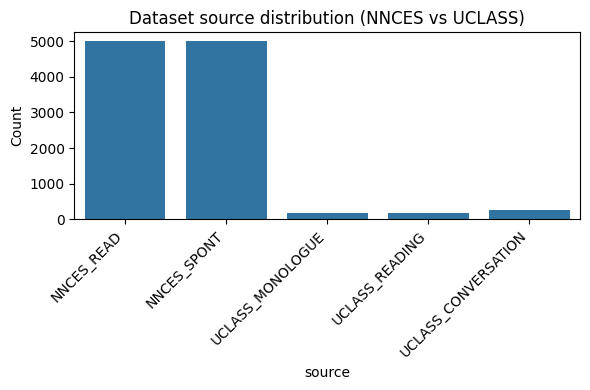

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="source", data=combined)
plt.title("Dataset source distribution (NNCES vs UCLASS)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Filtering combined dataset to have only English values**

In [ ]:
# Deterministic results for langdetect
DetectorFactory.seed = 0

COMBINED_PATH = "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA/combined_nnces_uclass_transcripts.csv"
OUT_ENG = COMBINED_PATH.replace(".csv", "_english_only.csv")
OUT_NON = COMBINED_PATH.replace(".csv", "_non_english.csv")

# Load
df = pd.read_csv(COMBINED_PATH)
print("Loaded combined rows:", len(df))

# Regex ranges for common non-Latin scripts (covers many languages)
NON_LATIN_RE = re.compile(
    "[" +
    "\u0400-\u04FF" +  # Cyrillic
    "\u0370-\u03FF" +  # Greek
    "\u0600-\u06FF" +  # Arabic
    "\u0900-\u097F" +  # Devanagari (Hindi)
    "\u0B80-\u0BFF" +  # Tamil, Telugu blocks (some)
    "\u4E00-\u9FFF" +  # CJK Unified Ideographs (Chinese/Japanese/Korean)
    "\u0980-\u09FF" +  # Bengali
    "\u0A00-\u0A7F" +  # Gurmukhi (Punjabi)
    "\u0C00-\u0C7F" +  # Telugu
    "\u0D00-\u0D7F" +  # Malayalam
    "]"
)

# Helper functions
def has_non_latin_chars(text):
    if not isinstance(text, str):
        return False
    return bool(NON_LATIN_RE.search(text))

def count_words(text):
    if not isinstance(text, str):
        return 0
    return len([w for w in re.findall(r"\w+", text) if len(w) > 0])

def detect_lang_safe(text):
    try:
        return detect(text)
    except:
        return "und"

# Decision rule:
# 1) If transcript contains non-latin script -> mark non-English
# 2) Else if transcript has >= 3 words -> run langdetect and require 'en' to accept
# 3) Else (short utterances: 0-2 words) -> accept only if all characters are Latin letters/numbers/punct

is_english = []
lang_detected = []
script_flag = []

for idx, row in df.iterrows():
    txt = row.get("transcript", "")
    if not isinstance(txt, str):
        txt = str(txt)

    txt_stripped = txt.strip()

    # Script check
    non_latin = has_non_latin_chars(txt_stripped)
    script_flag.append(non_latin)

    if non_latin:
        # contains non-Latin characters -> non-English
        is_english.append(False)
        lang_detected.append("non_latin")
        continue

    # Count words
    nwords = count_words(txt_stripped)

    if nwords >= 3:
        lang = detect_lang_safe(txt_stripped)
        lang_detected.append(lang)
        if lang == "en":
            is_english.append(True)
        else:
            is_english.append(False)
    else:
        if re.search(r"[A-Za-z]", txt_stripped):
            is_english.append(True)
            lang_detected.append("short_latin")
        else:
            is_english.append(False)
            lang_detected.append("short_non_latin_or_und")

# Attaching results to dataframe
df["detected_lang"] = lang_detected
df["has_non_latin_script"] = script_flag
df["is_english"] = is_english

# Split
eng_df = df[df["is_english"] == True].copy()
non_df = df[df["is_english"] == False].copy()

# Saving outputs
eng_df.to_csv(OUT_ENG, index=False)
non_df.to_csv(OUT_NON, index=False)

# Summary
print("Total rows:", len(df))
print("English-only rows kept:", len(eng_df))
print("Non-English/removed rows:", len(non_df))
print()
print("Sample non-English reasons (first 10):")
print(non_df[["transcript","detected_lang","has_non_latin_script"]].head(10))

print("\nSaved files:")
print("English CSV:", OUT_ENG)
print("Non-English CSV:", OUT_NON)


Loaded combined rows: 10603
Total rows: 10603
English-only rows kept: 6196
Non-English/removed rows: 4407

Sample non-English reasons (first 10):
                                           transcript detected_lang  \
0   विंटर कोसके लिएज़ें हो भात करता हिस्रान का पास...     non_latin   
2                 ूई दालो ूई आई रुछाूत ूई और नागाूर ॥     non_latin   
4   अआप कोई मैं ब्राडन्वादर मैं अवादा दो बहुतिर क्...     non_latin   
5                   अंने ४, अंने ४, ४, ४, ४, ४, . . .     non_latin   
6   नहीं की लगता है, अगरा एक भी लागता है, अजो आदा ...     non_latin   
8   आप श्चबाद कुए ठीया कुए कुए प्रद गुए प्रद बादता...     non_latin   
9                                        आद असरे रगा।     non_latin   
10                           आंगर मेरेला खा街, मेरेला.     non_latin   
11  ब्द्एक्ट्या Meana is very attractive and full ...     non_latin   
12  नाचर is ye,  केरीजर यास और मादर,  थान तो जीखा ...     non_latin   

    has_non_latin_script  
0                   True  
2                 

**Dataset overview - visualization**

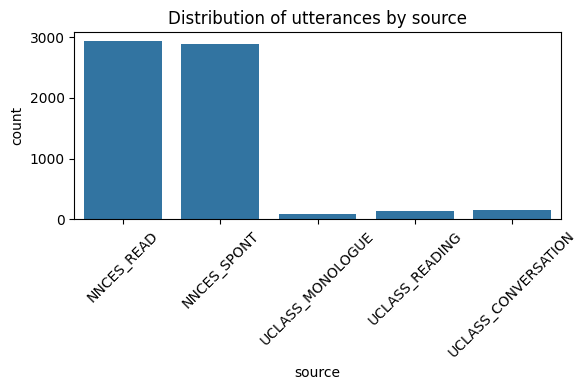

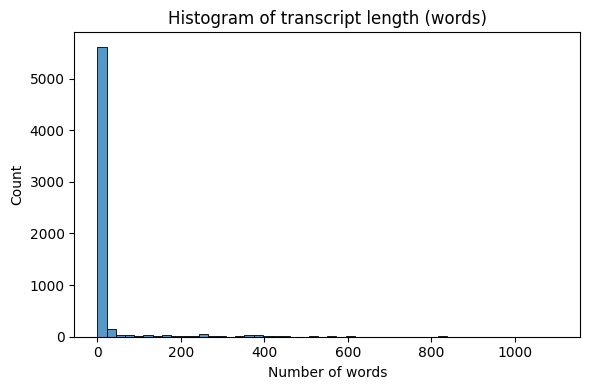

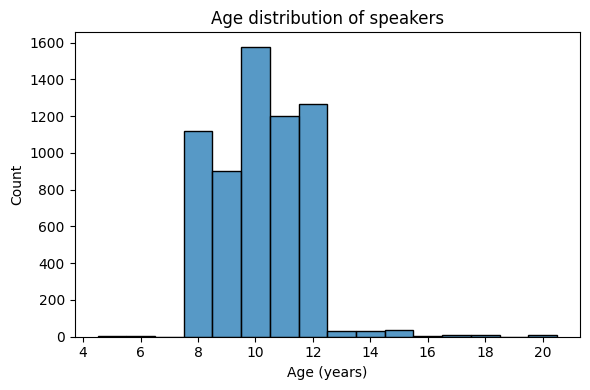

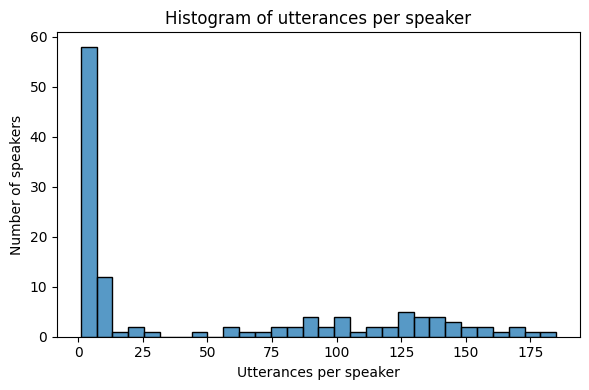

In [ ]:
COMBINED_PATH = os.path.join(METADATA_DIR, "combined_nnces_uclass_transcripts_english_only.csv")
df = pd.read_csv(COMBINED_PATH)
# ---- Basic source distribution ----
plt.figure(figsize=(6,4))
sns.countplot(x="source", data=df)
plt.xticks(rotation=45)
plt.title("Distribution of utterances by source")
plt.tight_layout()
plt.show()

# ---- Transcript length (words) ----
df["n_words"] = df["transcript"].fillna("").apply(lambda t: len(re.findall(r"\w+", str(t))))
plt.figure(figsize=(6,4))
sns.histplot(df["n_words"], bins=50)
plt.title("Histogram of transcript length (words)")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ---- Age distribution (if age available) ----
if "age" in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df["age"].dropna(), bins=20, discrete=True)
    plt.title("Age distribution of speakers")
    plt.xlabel("Age (years)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# ---- Utterances per speaker ----
if "speaker_id" in df.columns:
    spk_counts = df["speaker_id"].value_counts()
    plt.figure(figsize=(6,4))
    sns.histplot(spk_counts, bins=30)
    plt.title("Histogram of utterances per speaker")
    plt.xlabel("Utterances per speaker")
    plt.ylabel("Number of speakers")
    plt.tight_layout()
    plt.show()


**Dataset split**

In [10]:
COMBINED_PATH = os.path.join(METADATA_DIR, "combined_nnces_uclass_transcripts_english_only.csv")
OUT_TRAIN = os.path.join(METADATA_DIR, "train_split.csv")
OUT_VAL = os.path.join(METADATA_DIR, "val_split.csv")
OUT_TEST = os.path.join(METADATA_DIR, "test_split.csv")

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Loading combined dataframe
df = pd.read_csv(COMBINED_PATH)
print("Loaded combined rows:", len(df))

# Ensuring if speaker_id exists
def derive_speaker(path):
    if not isinstance(path, str):
        return "unknown"
    base = os.path.basename(path).replace(".wav","")
    parts = base.split("_")
    if len(parts) >= 2:
        return f"{parts[0]}_{parts[1]}"
    return parts[0]

if "speaker_id" not in df.columns:
    df["speaker_id"] = df["audio_path"].apply(derive_speaker)
else:
    df["speaker_id"] = df.apply(lambda r: r["speaker_id"] if pd.notna(r["speaker_id"]) and r["speaker_id"]!="" else derive_speaker(r["audio_path"]), axis=1)

# Listing unique speakers
speakers = sorted(df["speaker_id"].unique().tolist())
print("Unique speakers:", len(speakers))

# Splitting speakers (70/15/15)
train_spks, rest_spks = train_test_split(speakers, test_size=0.3, random_state=RANDOM_SEED)
val_spks, test_spks = train_test_split(rest_spks, test_size=0.5, random_state=RANDOM_SEED)

print("Speakers -> train:", len(train_spks), "val:", len(val_spks), "test:", len(test_spks))

# Assigning split to each row based on speaker_id
def assign_split(speaker):
    if speaker in train_spks: return "train"
    if speaker in val_spks: return "val"
    return "test"

df["split"] = df["speaker_id"].apply(assign_split)

# Saving splits
train_df = df[df["split"]=="train"].reset_index(drop=True)
val_df = df[df["split"]=="val"].reset_index(drop=True)
test_df = df[df["split"]=="test"].reset_index(drop=True)

train_df.to_csv(OUT_TRAIN, index=False)
val_df.to_csv(OUT_VAL, index=False)
test_df.to_csv(OUT_TEST, index=False)

print("Saved train/val/test:")
print(" train rows:", len(train_df))
print(" val rows:  ", len(val_df))
print(" test rows: ", len(test_df))

print("\nCounts by source and split:")
print(pd.crosstab(df["split"], df.get("source", "unknown")))

# Saving speaker lists for reproducibility
with open(os.path.join(METADATA_DIR, "train_speakers.txt"), "w") as f:
    f.write("\n".join(train_spks))
with open(os.path.join(METADATA_DIR, "val_speakers.txt"), "w") as f:
    f.write("\n".join(val_spks))
with open(os.path.join(METADATA_DIR, "test_speakers.txt"), "w") as f:
    f.write("\n".join(test_spks))

print("Speaker lists saved in METADATA_DIR.")


Loaded combined rows: 6196
Unique speakers: 123
Speakers -> train: 86 val: 18 test: 19
Saved train/val/test:
 train rows: 4106
 val rows:   650
 test rows:  1440

Counts by source and split:
source  NNCES_READ  NNCES_SPONT  UCLASS_CONVERSATION  UCLASS_MONOLOGUE  \
split                                                                    
test           717          680                   19                 7   
train         1915         1918                  108                60   
val            304          298                   18                15   

source  UCLASS_READING  
split                   
test                17  
train              105  
val                 15  
Speaker lists saved in METADATA_DIR.


**Dataset split (Train/test/val) - Visualization**

<Figure size 700x400 with 0 Axes>

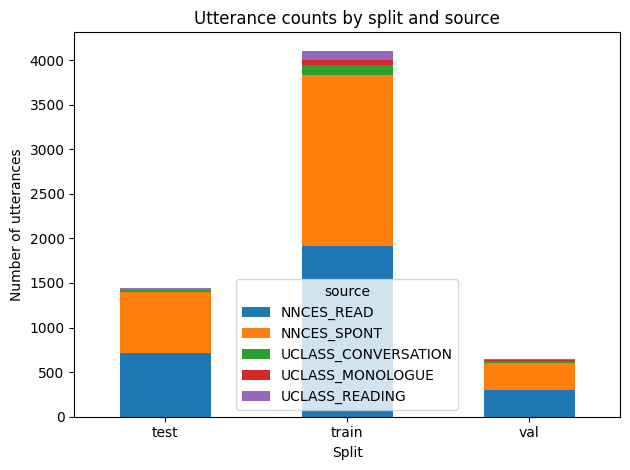

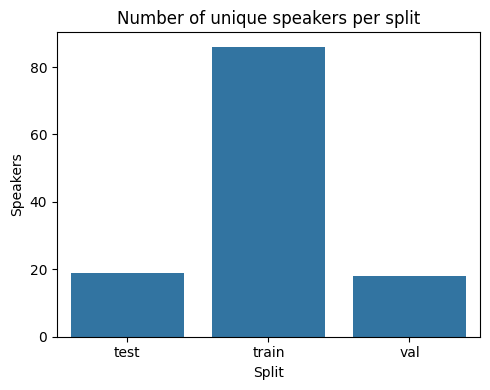

In [ ]:
split_source = pd.crosstab(df["split"], df.get("source", "unknown"))

plt.figure(figsize=(7,4))
split_source.plot(kind="bar", stacked=True)
plt.title("Utterance counts by split and source")
plt.xlabel("Split")
plt.ylabel("Number of utterances")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Speakers per split
spk_split = df.groupby("split")["speaker_id"].nunique()
plt.figure(figsize=(5,4))
sns.barplot(x=spk_split.index, y=spk_split.values)
plt.title("Number of unique speakers per split")
plt.xlabel("Split")
plt.ylabel("Speakers")
plt.tight_layout()
plt.show()


In [ ]:
pd.crosstab(df["split"], df["source"])


source,NNCES_READ,NNCES_SPONT,UCLASS_CONVERSATION,UCLASS_MONOLOGUE,UCLASS_READING
split,,,,,
test,717,680,19,7,17
train,1915,1918,108,60,105
val,304,298,18,15,15


In [ ]:
df.groupby("split")["speaker_id"].nunique()


,speaker_id
split,
test,19
train,86
val,18


**Text augmentation**

In [ ]:
# Text disfluency detector
import re
import numpy as np


def word_tokens(text):
    if not isinstance(text, str):
        return []
    return re.findall(r"[A-Za-z0-9]+(?:-[A-Za-z0-9]+)*", text)



#Repetition detection

# Adjacent repeat: "I I I", "go go go"
re_adj_repeat = re.compile(r'\b([A-Za-z0-9]+)\b(?:\s+\1\b)+', re.IGNORECASE)

# Hyphen repeat: "ca-ca-cat", "la-la"
re_hyph_repeat = re.compile(r'\b([A-Za-z0-9]{1,})-(?:\1(?:-|\b))+', re.IGNORECASE)

def count_repetitions(text):
    if not isinstance(text, str):
        return 0

    adj = len(re_adj_repeat.findall(text))
    hyph = len(re_hyph_repeat.findall(text))

    # long-word repetition
    toks = word_tokens(text)
    run_count = 0
    if toks:
        prev = toks[0].lower()
        run_len = 1
        for t in toks[1:]:
            t_l = t.lower()
            if t_l == prev:
                run_len += 1
            else:
                if run_len >= 2:
                    run_count += 1
                run_len = 1
            prev = t_l
        if run_len >= 2:
            run_count += 1

    return adj + hyph + run_count


#Prolongation detection

# Detect repeated vowels ≥3 times: sooooo, heeello
re_prolong = re.compile(r'[aeiouAEIOU]{3,}')

def count_prolongations(text):
    if not isinstance(text, str): return 0
    return len(re_prolong.findall(text))

#Filled pause detection

FILLED = {"um","uh","erm","uhm","hmm","mm","ah","oh","eh"}

def count_filled_pauses(text):
    if not isinstance(text, str): return 0
    toks = [t.lower() for t in re.findall(r"[A-Za-z0-9]+", text)]
    return sum(t in FILLED for t in toks)


#Test
tests = [
    "I I I want to go",
    "ca-ca-cat is here",
    "sooooo I am happy",
    "um I uh went",
    "Mom and dad dad daddd arrived",
    "This is normal"
]

for t in tests:
    print(f"TEXT: {t}")
    print(" reps:", count_repetitions(t),
          " prolong:", count_prolongations(t),
          " filled:", count_filled_pauses(t))
    print("-------------------")


TEXT: I I I want to go
 reps: 2  prolong: 0  filled: 0
-------------------
TEXT: ca-ca-cat is here
 reps: 1  prolong: 0  filled: 0
-------------------
TEXT: sooooo I am happy
 reps: 0  prolong: 1  filled: 0
-------------------
TEXT: um I uh went
 reps: 0  prolong: 0  filled: 2
-------------------
TEXT: Mom and dad dad daddd arrived
 reps: 2  prolong: 0  filled: 0
-------------------
TEXT: This is normal
 reps: 0  prolong: 0  filled: 0
-------------------


In [12]:
#Triple level text augmentation (Mild, moderate, severe)

random.seed(42)

METADATA_DIR = "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA"
TRAIN_PATH = os.path.join(METADATA_DIR, "train_split.csv")

OUT_PATH = os.path.join(METADATA_DIR, "train_text_augmented_triple.csv")

# Load train split
train_df = pd.read_csv(TRAIN_PATH)
print("Original train rows:", len(train_df))

# Applying text augmentation only to NNCES
nnces_df = train_df[train_df["source"].str.upper().str.contains("NNCES")].copy()
print("NNCES rows:", len(nnces_df))

def mild_aug(word):
    """Minimal disfluency."""
    if random.random() < 0.03:
        return "um " + word
    return word

def moderate_aug(word):
    """Moderate disfluency."""
    r = random.random()
    if r < 0.20:        # moderate whole word repeat
        return f"{word} {word}"
    elif r < 0.35:      # moderate prefix
        return f"{word[:2]}-{word[:2]}-{word}"
    elif r < 0.45:      # moderate prolongation
        return re_prolong_word(word)
    return word

def severe_aug(word):
    """Severe stuttering."""
    r = random.random()
    if r < 0.40:
        return f"{word} {word} {word}"
    elif r < 0.70:
        return f"{word[:2]}-" * 3 + word
    else:
        return re_prolong_word(word)


def re_prolong_word(word):
    """Add strong vowel prolongation."""
    for i, ch in enumerate(word):
        if ch.lower() in "aeiou":
            return word[:i] + ch * random.randint(4,7) + word[i+1:]
    return word

aug_rows = []

for _, row in nnces_df.iterrows():
    txt = row["transcript"]
    if not isinstance(txt, str) or not txt.strip():
        continue

    words = txt.split()

    # Mild
    mild_words = [mild_aug(w) for w in words]
    r_mild = row.copy()
    r_mild["transcript"] = " ".join(mild_words)
    r_mild["aug_type"] = "text_mild"
    aug_rows.append(r_mild)

    # Moderate version
    mod_words = [moderate_aug(w) for w in words]
    r_mod = row.copy()
    r_mod["transcript"] = " ".join(mod_words)
    r_mod["aug_type"] = "text_moderate"
    aug_rows.append(r_mod)

    # Severe version
    sev_words = [severe_aug(w) for w in words]
    r_sev = row.copy()
    r_sev["transcript"] = " ".join(sev_words)
    r_sev["aug_type"] = "text_severe"
    aug_rows.append(r_sev)


aug_df = pd.DataFrame(aug_rows)
print("\nAugmented rows created:", len(aug_df))
print(aug_df["aug_type"].value_counts())


# Merge original + augmented
final = pd.concat([train_df, aug_df], ignore_index=True)
print("\nFinal rows after triple augmentation:", len(final))

final.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)


Original train rows: 4106
NNCES rows: 3833

Augmented rows created: 11463
aug_type
text_mild        3821
text_moderate    3821
text_severe      3821
Name: count, dtype: int64

Final rows after triple augmentation: 15569
Saved: /content/drive/MyDrive/STUTTERING_WHISPER/METADATA/train_text_augmented_triple.csv


**Audio augmentation**

In [ ]:
# Triple-Level Audio Augmentation (mild/moderate/severe)

random.seed(42)

METADATA_DIR = "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA"
AUG_DIR = "/content/drive/MyDrive/STUTTERING_WHISPER/AUDIO_AUG"
os.makedirs(AUG_DIR, exist_ok=True)

TRAIN_TXT_AUG = os.path.join(METADATA_DIR, "train_text_augmented_triple.csv")

df = pd.read_csv(TRAIN_TXT_AUG)
print("Loaded rows:", len(df))

SAMPLE_ROWS = df.copy()
print("Audio augmentation target rows:", len(SAMPLE_ROWS))


def aug_mild(y, sr):
    """Minimal distortion."""
    # Add very tiny white noise
    noise = np.random.normal(0, 0.001, len(y))
    y2 = y + noise

    # Tiny silence insertion
    sil = np.zeros(int(0.05 * sr))
    y2 = np.concatenate([y2, sil])

    return y2, "audio_mild"


def aug_moderate(y, sr):
    """Moderate distortion."""
    # Stretch part of the audio
    try:
        y_stretch = librosa.effects.time_stretch(y.astype(np.float32), rate=0.9)
    except:
        y_stretch = y

    # Insert silence
    sil = np.zeros(int(0.15 * sr))
    pos = int(len(y_stretch) * 0.5)
    y2 = np.concatenate([y_stretch[:pos], sil, y_stretch[pos:]])

    return y2, "audio_moderate"


def aug_severe(y, sr):
    """Strong distortion."""
    # Duplicate start chunk
    prefix = y[:int(0.1 * sr)]
    y2 = np.concatenate([prefix, prefix, y])  # heavy prefix

    # Insert long silence
    sil = np.zeros(int(0.3 * sr))
    pos = int(len(y2) * 0.3)
    y2 = np.concatenate([y2[:pos], sil, y2[pos:]])

    # RMS drop (heavy reduction)
    y2 = y2 * 0.6

    return y2, "audio_severe"


aug_rows = []

for _, row in tqdm(SAMPLE_ROWS.iterrows(), total=len(SAMPLE_ROWS), desc="AUDIO-AUG"):
    src = row["audio_path"]
    try:
        y, sr = librosa.load(src, sr=None)
    except:
        continue

    # Mild
    y_m, tag_m = aug_mild(y, sr)
    out_m = os.path.join(AUG_DIR, os.path.basename(src).replace(".wav", "_mild.wav"))
    sf.write(out_m, y_m, sr)

    r_m = row.copy()
    r_m["audio_path"] = out_m
    r_m["aug_type"] = tag_m
    r_m["is_augmented"] = True
    aug_rows.append(r_m)

    # Moderate
    y_md, tag_md = aug_moderate(y, sr)
    out_md = os.path.join(AUG_DIR, os.path.basename(src).replace(".wav", "_moderate.wav"))
    sf.write(out_md, y_md, sr)

    r_md = row.copy()
    r_md["audio_path"] = out_md
    r_md["aug_type"] = tag_md
    r_md["is_augmented"] = True
    aug_rows.append(r_md)

    # Severe
    y_s, tag_s = aug_severe(y, sr)
    out_s = os.path.join(AUG_DIR, os.path.basename(src).replace(".wav", "_severe.wav"))
    sf.write(out_s, y_s, sr)

    r_s = row.copy()
    r_s["audio_path"] = out_s
    r_s["aug_type"] = tag_s
    r_s["is_augmented"] = True
    aug_rows.append(r_s)

# SAVE METADATA
AUG_META = os.path.join(METADATA_DIR, "train_audio_augmented_triple.csv")
aug_df = pd.DataFrame(aug_rows)
aug_df.to_csv(AUG_META, index=False)

print("\nAUDIO-TRIPLE AUG DONE")
print("Created rows:", len(aug_df))
print(aug_df["aug_type"].value_counts())
print("Saved:", AUG_META)


Loaded rows: 15569
Audio augmentation target rows: 15569


AUDIO-AUG:  81%|████████▏ | 12657/15569 [2:20:30<41:40,  1.16it/s]

In [16]:
#Rebuild audio augmentation metadata

METADATA_DIR = "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA"
AUG_DIR = "/content/drive/MyDrive/STUTTERING_WHISPER/AUDIO_AUG"

TRAIN_TXT_AUG = os.path.join(METADATA_DIR, "train_text_augmented_triple.csv")
AUG_META = os.path.join(METADATA_DIR, "train_audio_augmented_triple.csv")

# Load source training rows
src_df = pd.read_csv(TRAIN_TXT_AUG)
print("Source rows loaded:", len(src_df))

# Map base filename -> original row
src_df["base"] = src_df["audio_path"].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)
base2row = {r["base"]: r for _, r in src_df.iterrows()}

# Scan augmented audio directory
rows = []

files = os.listdir(AUG_DIR)
print("Audio files found:", len(files))

for f in files:
    if not f.endswith(".wav"):
        continue

    if "_mild.wav" in f:
        aug_type = "audio_mild"
        base = f.replace("_mild.wav", "")
    elif "_moderate.wav" in f:
        aug_type = "audio_moderate"
        base = f.replace("_moderate.wav", "")
    elif "_severe.wav" in f:
        aug_type = "audio_severe"
        base = f.replace("_severe.wav", "")
    else:
        continue

    if base not in base2row:
        continue

    r = base2row[base].copy()
    r["audio_path"] = os.path.join(AUG_DIR, f)
    r["aug_type"] = aug_type
    r["is_augmented"] = True
    rows.append(r)

# Save metadata
aug_df = pd.DataFrame(rows)
aug_df.to_csv(AUG_META, index=False)

print("\nREBUILD COMPLETE")
print("Metadata rows:", len(aug_df))
print(aug_df["aug_type"].value_counts())
print("Saved to:", AUG_META)


Source rows loaded: 15569
Audio files found: 8577

REBUILD COMPLETE
Metadata rows: 8577
aug_type
audio_mild        2859
audio_severe      2859
audio_moderate    2859
Name: count, dtype: int64
Saved to: /content/drive/MyDrive/STUTTERING_WHISPER/METADATA/train_audio_augmented_triple.csv


**Merging augmented rows**

In [103]:
METADATA_DIR = "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA"
AUG_META = os.path.join(METADATA_DIR, "train_audio_augmented_triple.csv")

df = pd.read_csv(AUG_META)

print("Total augmented rows:", len(df))

orig_df = pd.read_csv(
    "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA/train_text_augmented_triple.csv"
)

sample_row = orig_df[orig_df["audio_path"].apply(lambda x: isinstance(x,str) and os.path.exists(x))].iloc[0]

orig_path = sample_row["audio_path"]

aug_samples = df[df["audio_path"].str.contains(os.path.basename(orig_path).replace(".wav",""), na=False)]


Total augmented rows: 8577


**Waveform comparison**

In [108]:
y_orig, sr = librosa.load(orig_path, sr=None)

augmented = {}
for _, r in aug_samples.iterrows():
    tag = r["aug_type"]
    path = r["audio_path"]
    if os.path.exists(path):
        augmented[tag] = librosa.load(path, sr=sr)[0]


In [117]:
AUG_DIR = "/content/drive/MyDrive/STUTTERING_WHISPER/AUDIO_AUG"

# Pick ONE augmented file
aug_files = [f for f in os.listdir(AUG_DIR) if f.endswith("_severe.wav")]

if len(aug_files) == 0:
    raise RuntimeError("No augmented audio files found!")

aug_severe_path = os.path.join(AUG_DIR, aug_files[0])

# Derive original filename
orig_name = aug_files[0].replace("_severe.wav", ".wav")

# Search original in dataset folders
DATASET_ROOT = "/content/drive/MyDrive/STUTTERING_WHISPER/DATASET"

orig_path = None
for root, _, files in os.walk(DATASET_ROOT):
    if orig_name in files:
        orig_path = os.path.join(root, orig_name)
        break

if orig_path is None:
    raise RuntimeError("Original audio file not found!")

print("Original:", orig_path)
print("Augmented:", aug_severe_path)


Original: /content/drive/MyDrive/STUTTERING_WHISPER/DATASET/NNCES/Read_Speech_Data/Read_Speech_Data/11Y/Boys_11/M20/M20_03/M20_03_09.wav
Augmented: /content/drive/MyDrive/STUTTERING_WHISPER/AUDIO_AUG/M20_03_09_severe.wav


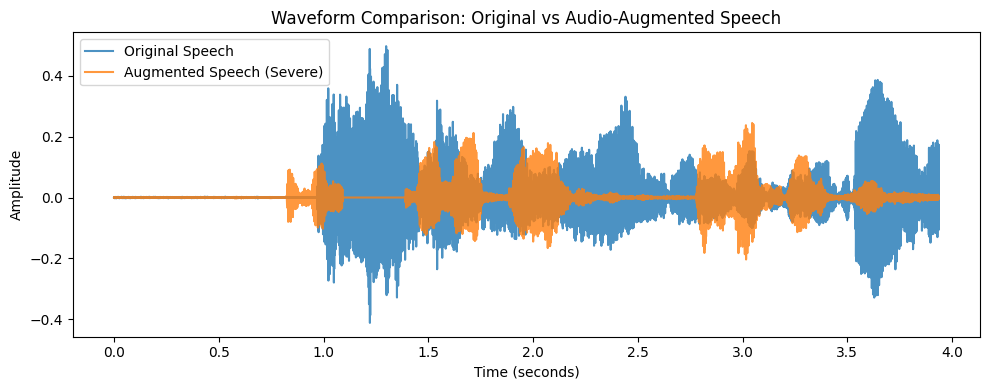

In [118]:
# Load audio
y_orig, sr = librosa.load(orig_path, sr=None)
y_aug, _   = librosa.load(aug_severe_path, sr=sr)

# Trim to same length for fair comparison
min_len = min(len(y_orig), len(y_aug))
y_orig = y_orig[:min_len]
y_aug  = y_aug[:min_len]

time = np.linspace(0, min_len / sr, min_len)

# Plot
plt.figure(figsize=(10, 4))

plt.plot(time, y_orig, label="Original Speech", alpha=0.8)
plt.plot(time, y_aug, label="Augmented Speech (Severe)", alpha=0.8)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Waveform Comparison: Original vs Audio-Augmented Speech")
plt.legend()
plt.tight_layout()
plt.show()


**Feature extraction**

In [ ]:
# BLOCK 4 — Feature Extraction (Audio + Text)

METADATA_DIR = "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA"
AUG_AUDIO_META = os.path.join(METADATA_DIR, "train_audio_augmented_triple.csv")
TRAIN_TXT_AUG  = os.path.join(METADATA_DIR, "train_text_augmented_triple.csv")
VAL_SPLIT  = os.path.join(METADATA_DIR, "val_split.csv")
TEST_SPLIT = os.path.join(METADATA_DIR, "test_split.csv")

OUT_FEATURES = os.path.join(METADATA_DIR, "features_all_samples.csv")

# Robust text disfluency detectors
FILLED = set(["um","uh","uhm","erm","hmm","mm","ah","oh","eh"])

def safe_text(x):
    if isinstance(x, str):
        return x
    return ""

def count_repetitions(text):
    text = safe_text(text).lower()
    return len(re.findall(r"\b(\w+)\s+\1\b", text))

def count_filled_pauses(text):
    toks = re.findall(r"\w+", safe_text(text).lower())
    return sum(t in FILLED for t in toks)

def count_prolongations(text):
    return len(re.findall(r"(.)\1{2,}", safe_text(text).lower()))

# Load data
train_df = pd.read_csv(TRAIN_TXT_AUG)
val_df   = pd.read_csv(VAL_SPLIT)
test_df  = pd.read_csv(TEST_SPLIT)

# Add audio-augmented rows into train
if os.path.exists(AUG_AUDIO_META):
    aug_audio_df = pd.read_csv(AUG_AUDIO_META)
    train_df = pd.concat([train_df, aug_audio_df], ignore_index=True)

print("Train rows (with audio aug):", len(train_df))
print("Val rows:", len(val_df))
print("Test rows:", len(test_df))

all_df = pd.concat(
    [train_df.assign(split="train"),
     val_df.assign(split="val"),
     test_df.assign(split="test")],
    ignore_index=True
)

print("Total rows for feature extraction:", len(all_df))

# Feature extraction loop
features = []

for _, row in tqdm(all_df.iterrows(), total=len(all_df), desc="FEATURE-EXTRACT"):
    ap = row["audio_path"]
    txt = safe_text(row.get("transcript", ""))

    # ---------- TEXT FEATURES ----------
    rep = count_repetitions(txt)
    fill = count_filled_pauses(txt)
    pro = count_prolongations(txt)

    # ---------- AUDIO FEATURES ----------
    try:
        y, sr = librosa.load(ap, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)
        rms = float(librosa.feature.rms(y=y).mean())

        intervals = librosa.effects.split(y, top_db=25)
        speech_dur = sum((end - start) for start, end in intervals) / sr

        pauses = []
        for i in range(len(intervals)-1):
            gap = (intervals[i+1][0] - intervals[i][1]) / sr
            if gap > 0:
                pauses.append(gap)

        n_pauses = len(pauses)
        total_pause = sum(pauses)
        avg_pause = total_pause / n_pauses if n_pauses > 0 else 0
        speech_rate = len(txt.split()) / speech_dur if speech_dur > 0 else 0

    except:
        duration = speech_dur = rms = n_pauses = total_pause = avg_pause = speech_rate = 0

    features.append({
        "audio_path": ap,
        "split": row["split"],
        "repetition_count": rep,
        "filled_pause_count": fill,
        "prolongation_count": pro,
        "audio_duration": duration,
        "speech_duration": speech_dur,
        "n_pauses": n_pauses,
        "total_pause_duration": total_pause,
        "avg_pause": avg_pause,
        "rms_mean": rms,
        "speech_rate_wps": speech_rate
    })

feat_df = pd.DataFrame(features)
feat_df.to_csv(OUT_FEATURES, index=False)

print("\nFEATURE EXTRACTION COMPLETE")
print("Saved to:", OUT_FEATURES)
print(feat_df.describe())


In [58]:
# Paths
FEATURES = "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA/features_all_samples.csv"
TRAIN_SPLIT = "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA/train_split.csv"
VAL_SPLIT   = "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA/val_split.csv"
TEST_SPLIT  = "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA/test_split.csv"

# Load
feat = pd.read_csv(FEATURES)
train = pd.read_csv(TRAIN_SPLIT)
val   = pd.read_csv(VAL_SPLIT)
test  = pd.read_csv(TEST_SPLIT)

# Merge
train_m = train.merge(feat, on="audio_path", how="inner")
val_m   = val.merge(feat, on="audio_path", how="inner")
test_m  = test.merge(feat, on="audio_path", how="inner")

print("Rows after merge:")
print("Train:", len(train_m))
print("Val  :", len(val_m))
print("Test :", len(test_m))

# Save
train_m.to_csv("train_with_features.csv", index=False)
val_m.to_csv("val_with_features.csv", index=False)
test_m.to_csv("test_with_features.csv", index=False)


Rows after merge:
Train: 15569
Val  : 650
Test : 1440


**Heuristic Severity Labelling**

In [59]:
# Load merged files
train = pd.read_csv("train_with_features.csv")
val   = pd.read_csv("val_with_features.csv")
test  = pd.read_csv("test_with_features.csv")

# Severity score
def compute_severity(df):
    return (
        1.2 * df["repetition_count"] +
        1.0 * df["prolongation_count"] +
        0.8 * df["filled_pause_count"] +
        0.6 * df["total_pause_duration"] +
        (1.0 / (df["speech_rate_wps"] + 1e-3))
    )

train["severity_score"] = compute_severity(train)
val["severity_score"]   = compute_severity(val)
test["severity_score"]  = compute_severity(test)

# Train-based thresholds
q1 = train["severity_score"].quantile(0.33)
q2 = train["severity_score"].quantile(0.66)

print(f"Train thresholds → mild ≤ {q1:.3f}, moderate ≤ {q2:.3f}")

def assign_label(score):
    if score <= q1:
        return "mild"
    elif score <= q2:
        return "moderate"
    else:
        return "severe"

for df in [train, val, test]:
    df["severity_label"] = df["severity_score"].apply(assign_label)

# Sanity checks
print("\nTRAIN label distribution:")
print(train["severity_label"].value_counts())

print("\nVAL label distribution:")
print(val["severity_label"].value_counts())

print("\nTEST label distribution:")
print(test["severity_label"].value_counts())

# Save
train.to_csv("train_labeled.csv", index=False)
val.to_csv("val_labeled.csv", index=False)
test.to_csv("test_labeled.csv", index=False)


Train thresholds → mild ≤ 1.307, moderate ≤ 5.438

TRAIN label distribution:
severity_label
severe      5294
mild        5138
moderate    5137
Name: count, dtype: int64

VAL label distribution:
severity_label
mild        448
moderate    149
severe       53
Name: count, dtype: int64

TEST label distribution:
severity_label
mild        1002
moderate     391
severe        47
Name: count, dtype: int64


####**Multimodal model**

**Building PyTorch dataset**

In [60]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 8

NUMERIC_COLS = [
    "repetition_count",
    "prolongation_count",
    "filled_pause_count",
    "total_pause_duration",
    "speech_rate_wps",
    "rms_mean",
]

#Load data
train_df = pd.read_csv("train_labeled.csv")
val_df   = pd.read_csv("val_labeled.csv")
test_df  = pd.read_csv("test_labeled.csv")

print("Loaded rows →",
      "Train:", len(train_df),
      "Val:", len(val_df),
      "Test:", len(test_df))


#Load mapping (train)
labels = sorted(train_df["severity_label"].unique())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

print("Label mapping:", label2id)

train_df["label"] = train_df["severity_label"].map(label2id)
val_df["label"]   = val_df["severity_label"].map(label2id)
test_df["label"]  = test_df["severity_label"].map(label2id)


#Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class MultimodalDataset(Dataset):
    def __init__(self, df):
        self.texts = df["transcript"].fillna("").astype(str).tolist()
        self.numeric = df[NUMERIC_COLS].astype(float).values
        self.labels = df["label"].astype(int).values

        self.encodings = tokenizer(
            self.texts,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "numeric": torch.tensor(self.numeric[idx], dtype=torch.float),
            "labels": torch.tensor(self.labels[idx])
        }


#Build datasets
train_dataset = MultimodalDataset(train_df)
val_dataset   = MultimodalDataset(val_df)
test_dataset  = MultimodalDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Datasets & loaders created")


batch = next(iter(train_loader))

print("\nSANITY CHECK:")
print(" input_ids shape:", batch["input_ids"].shape)
print(" numeric shape:", batch["numeric"].shape)
print(" labels shape:", batch["labels"].shape)

assert batch["numeric"].shape[1] == len(NUMERIC_COLS), "Numeric dim mismatch!"



Loaded rows → Train: 15569 Val: 650 Test: 1440
Label mapping: {'mild': 0, 'moderate': 1, 'severe': 2}
Datasets & loaders created

SANITY CHECK:
 input_ids shape: torch.Size([8, 128])
 numeric shape: torch.Size([8, 6])
 labels shape: torch.Size([8])

BLOCK 3 COMPLETE — Data ready for model.


**Model training**

In [62]:
best_val_f1 = 0.0
best_epoch = -1
best_model_state = None

EPOCHS = 20

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc="Training", leave=False):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        numeric = batch["numeric"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask, numeric)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            numeric = batch["numeric"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask, numeric)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc, macro_f1


#Training loop
for epoch in range(1, EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{EPOCHS} =====")

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Val Macro F1 : {val_f1:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        print("✔ Best model updated")

# Load best model after all epochs
model.load_state_dict(best_model_state)

print("\nTRAINING COMPLETE")
print(f"Best Validation Macro F1: {best_val_f1:.4f} (Epoch {best_epoch})")



===== Epoch 1/20 =====


Train Loss : 1.0103
Train Acc  : 0.4786
Val Loss   : 0.9115
Val Acc    : 0.6908
Val Macro F1 : 0.6024
✔ Best model updated

===== Epoch 2/20 =====


Train Loss : 0.9338
Train Acc  : 0.5592
Val Loss   : 0.8088
Val Acc    : 0.7708
Val Macro F1 : 0.6601
✔ Best model updated

===== Epoch 3/20 =====


Train Loss : 0.8589
Train Acc  : 0.6314
Val Loss   : 0.8853
Val Acc    : 0.7585
Val Macro F1 : 0.7784
✔ Best model updated

===== Epoch 4/20 =====


Train Loss : 0.7890
Train Acc  : 0.6795
Val Loss   : 0.7756
Val Acc    : 0.8000
Val Macro F1 : 0.7862
✔ Best model updated

===== Epoch 5/20 =====


...

Train Loss : 0.5454
Train Acc  : 0.7728
Val Loss   : 0.7084
Val Acc    : 0.7754
Val Macro F1 : 0.7618

===== Epoch 17/20 =====


Train Loss : 0.5339
Train Acc  : 0.7790
Val Loss   : 0.7323
Val Acc    : 0.7846
Val Macro F1 : 0.7761

===== Epoch 18/20 =====


Train Loss : 0.5266
Train Acc  : 0.7823
Val Loss   : 0.7007
Val Acc    : 0.7954
Val Macro F1 : 0.7719

===== Epoch 19/20 =====


Train Loss : 0.5235
Train Acc  : 0.7843
Val Loss   : 0.7443
Val Acc    : 0.7785
Val Macro F1 : 0.7666

===== Epoch 20/20 =====


Train Loss : 0.5178
Train Acc  : 0.7864
Val Loss   : 0.7648
Val Acc    : 0.7754
Val Macro F1 : 0.7690

TRAINING COMPLETE
Best Validation Macro F1: 0.8076 (Epoch 6)


**Model evaluation**


===== FINAL TEST METRICS =====
Accuracy       : 0.7611
Macro Precision: 0.7878
Macro Recall   : 0.7748
Macro F1-score : 0.7809

===== CLASS-WISE REPORT =====
              precision    recall  f1-score   support

        mild     0.8199    0.8453    0.8324      1002
    moderate     0.5651    0.5217    0.5426       391
      severe     0.9783    0.9574    0.9677        47

    accuracy                         0.7611      1440
   macro avg     0.7878    0.7748    0.7809      1440
weighted avg     0.7559    0.7611    0.7581      1440



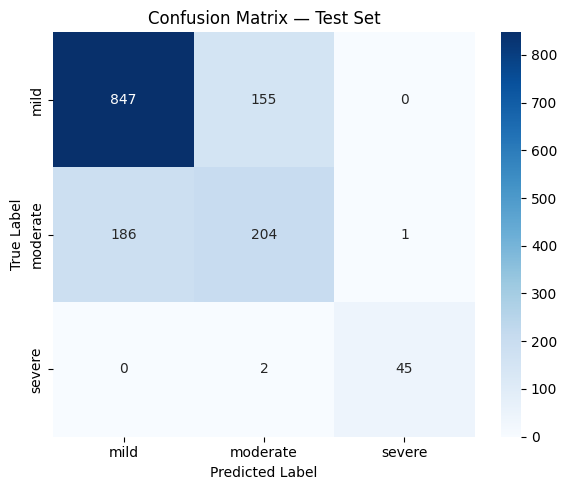

In [64]:
import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt


model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        numeric = batch["numeric"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask, numeric)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# METRICS
acc = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print("\n===== FINAL TEST METRICS =====")
print(f"Accuracy       : {acc:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1-score : {f1:.4f}")

# CLASS-WISE REPORT
print("\n===== CLASS-WISE REPORT =====")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[id2label[i] for i in range(len(id2label))],
        digits=4,
        zero_division=0
    )
)

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[id2label[i] for i in range(len(id2label))],
    yticklabels=[id2label[i] for i in range(len(id2label))]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


####**Unimodal - Text only**

In [56]:
# CONFIG
BASE_DIR = "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA"

TRAIN_CSV = os.path.join(BASE_DIR, "train_merged_for_model.csv")
VAL_CSV   = os.path.join(BASE_DIR, "val_merged_for_model.csv")
TEST_CSV  = os.path.join(BASE_DIR, "test_merged_for_model.csv")

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 8
EPOCHS = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [57]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Loaded rows →",
      "Train:", len(train_df),
      "Val:", len(val_df),
      "Test:", len(test_df))


Loaded rows → Train: 44605 Val: 650 Test: 1440


In [41]:
# LABEL MAPPING (TRAIN ONLY)
labels = sorted(train_df["severity_label"].unique())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

print("Label mapping:", label2id)

train_df["label"] = train_df["severity_label"].map(label2id)
val_df["label"]   = val_df["severity_label"].map(label2id)
test_df["label"]  = test_df["severity_label"].map(label2id)


Label mapping: {'mild': 0, 'moderate': 1, 'severe': 2}


In [42]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
class TextOnlyDataset(Dataset):
    def __init__(self, df):
        self.texts = df["transcript"].fillna("").astype(str).tolist()
        self.labels = df["label"].astype(int).values

        self.encodings = tokenizer(
            self.texts,
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels[idx])
        }


In [43]:
train_dataset = TextOnlyDataset(train_df)
val_dataset   = TextOnlyDataset(val_df)
test_dataset  = TextOnlyDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Datasets & loaders created")


Datasets & loaders created


In [44]:
# SANITY CHECK
batch = next(iter(train_loader))
print("\nSANITY CHECK:")
print(" input_ids shape:", batch["input_ids"].shape)
print(" attention_mask shape:", batch["attention_mask"].shape)
print(" labels shape:", batch["labels"].shape)



SANITY CHECK:
 input_ids shape: torch.Size([8, 128])
 attention_mask shape: torch.Size([8, 128])
 labels shape: torch.Size([8])


In [45]:
class TextOnlyClassifier(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(hidden, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls = outputs.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)
        return self.classifier(cls)


In [46]:
model = TextOnlyClassifier(MODEL_NAME, len(label2id)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)


In [47]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc="Training"):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


In [48]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = precision_recall_fscore_support(
        all_labels, all_preds, average="macro"
    )[2]

    return total_loss / len(loader), acc, f1


In [50]:
import os
import torch
import pandas as pd
import numpy as np

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import copy


In [51]:
best_model = None
best_val_f1 = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{EPOCHS} =====")

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f}")
    print(f"Val Macro F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model = copy.deepcopy(model.state_dict())
        print("✔ Best model saved")

model.load_state_dict(best_model)
print("\nTRAINING COMPLETE")



===== Epoch 1/20 =====


Evaluating: 100%|██████████| 82/82 [00:02<00:00, 34.72it/s]


Train Loss: 1.0079 | Train Acc: 0.4534
Val Loss  : 0.8955 | Val Acc  : 0.6954
Val Macro F1: 0.5644
✔ Best model saved

===== Epoch 2/20 =====


Evaluating: 100%|██████████| 82/82 [00:02<00:00, 34.55it/s]


Train Loss: 0.9848 | Train Acc: 0.4654
Val Loss  : 1.0100 | Val Acc  : 0.6092
Val Macro F1: 0.4162

===== Epoch 3/20 =====


...

Train Loss: 0.9069 | Train Acc: 0.4986
Val Loss  : 1.1286 | Val Acc  : 0.5169
Val Macro F1: 0.4290

===== Epoch 19/20 =====


Evaluating: 100%|██████████| 82/82 [00:02<00:00, 34.66it/s]


Train Loss: 0.9044 | Train Acc: 0.5017
Val Loss  : 0.9803 | Val Acc  : 0.6138
Val Macro F1: 0.4864

===== Epoch 20/20 =====


Evaluating: 100%|██████████| 82/82 [00:02<00:00, 34.52it/s]

Train Loss: 0.9029 | Train Acc: 0.5041
Val Loss  : 1.0907 | Val Acc  : 0.5892
Val Macro F1: 0.5197

TRAINING COMPLETE



===== FINAL TEST METRICS =====
Accuracy       : 0.6715
Macro Precision: 0.5188
Macro Recall   : 0.7137
Macro F1-score : 0.5422

===== CLASS-WISE REPORT =====
              precision    recall  f1-score   support

        mild     0.8367    0.7515    0.7918      1002
    moderate     0.4842    0.4322    0.4568       391
      severe     0.2356    0.9574    0.3782        47

    accuracy                         0.6715      1440
   macro avg     0.5188    0.7137    0.5422      1440
weighted avg     0.7214    0.6715    0.6873      1440



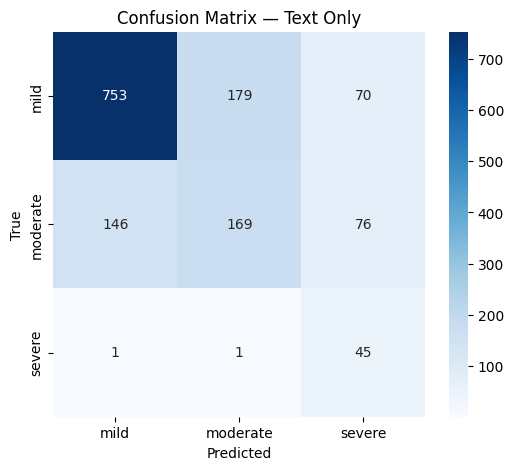

In [52]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        preds = logits.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro"
)

print("\n===== FINAL TEST METRICS =====")
print(f"Accuracy       : {acc:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1-score : {f1:.4f}")

print("\n===== CLASS-WISE REPORT =====")
print(classification_report(
    y_true, y_pred,
    target_names=[id2label[i] for i in range(len(id2label))],
    digits=4
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=id2label.values(),
    yticklabels=id2label.values()
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Text Only")
plt.show()


####**Unimodal - Audio only(prosodic)**

In [89]:
# CONFIG
BATCH_SIZE = 8
EPOCHS = 20
LR = 2e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

AUDIO_COLS = [
    "rms_mean",
    "audio_duration",
    "speech_duration"
]


# LOAD DATA
BASE_PATH = "/content/drive/MyDrive/STUTTERING_WHISPER/METADATA/"

train_df = pd.read_csv(BASE_PATH + "train_merged_for_model.csv")
val_df   = pd.read_csv(BASE_PATH + "val_merged_for_model.csv")
test_df  = pd.read_csv(BASE_PATH + "test_merged_for_model.csv")
print("Loaded rows →",
      "Train:", len(train_df),
      "Val:", len(val_df),
      "Test:", len(test_df))

labels = sorted(train_df["severity_label"].unique())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

print("Label mapping:", label2id)

train_df["label"] = train_df["severity_label"].map(label2id)
val_df["label"]   = val_df["severity_label"].map(label2id)
test_df["label"]  = test_df["severity_label"].map(label2id)

# HANDLE NaNs (important)
for col in AUDIO_COLS:
    median = train_df[col].median()
    train_df[col] = train_df[col].fillna(median)
    val_df[col]   = val_df[col].fillna(median)
    test_df[col]  = test_df[col].fillna(median)

# SCALE (TRAIN ONLY)
scaler = StandardScaler()
train_df[AUDIO_COLS] = scaler.fit_transform(train_df[AUDIO_COLS])
val_df[AUDIO_COLS]   = scaler.transform(val_df[AUDIO_COLS])
test_df[AUDIO_COLS]  = scaler.transform(test_df[AUDIO_COLS])

print("Audio prosodic features cleaned & scaled")



Loaded rows → Train: 44605 Val: 650 Test: 1440
Label mapping: {'mild': 0, 'moderate': 1, 'severe': 2}
Audio prosodic features cleaned & scaled


In [90]:
class AudioOnlyDataset(Dataset):
    def __init__(self, df):
        self.audio = df[AUDIO_COLS].values.astype(np.float32)
        self.labels = df["label"].values.astype(np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "audio": torch.tensor(self.audio[idx]),
            "labels": torch.tensor(self.labels[idx])
        }
train_dataset = AudioOnlyDataset(train_df)
val_dataset   = AudioOnlyDataset(val_df)
test_dataset  = AudioOnlyDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Sanity
batch = next(iter(train_loader))
print("SANITY CHECK audio shape:", batch["audio"].shape)



SANITY CHECK audio shape: torch.Size([8, 3])


In [91]:
import torch.nn as nn

class AudioOnlyModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )

    def forward(self, audio):
        return self.net(audio)
model = AudioOnlyModel(
    input_dim=len(AUDIO_COLS),
    num_classes=len(label2id)
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)


In [93]:
best_val_f1 = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{EPOCHS} =====")

    # -------- TRAIN --------
    model.train()
    train_loss, y_true, y_pred = 0, [], []

    for batch in tqdm(train_loader, desc="Training"):
        audio = batch["audio"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(audio)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        y_pred.extend(torch.argmax(logits, 1).cpu().numpy())
        y_true.extend(labels.cpu().numpy())

    train_acc = accuracy_score(y_true, y_pred)

    # -------- VAL --------
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in val_loader:
            audio = batch["audio"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            logits = model(audio)
            y_pred.extend(torch.argmax(logits, 1).cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    val_acc = accuracy_score(y_true, y_pred)
    val_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Train Loss : {train_loss/len(train_loader):.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Val Macro F1 : {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())
        print("Best model updated")

model.load_state_dict(best_state)
print("\nTRAINING COMPLETE")
print("Best Val Macro F1:", best_val_f1)




===== Epoch 1/20 =====


Training: 100%|██████████| 5576/5576 [00:20<00:00, 278.19it/s]


Train Loss : 1.0495
Train Acc  : 0.4215
Val Acc    : 0.5523
Val Macro F1 : 0.4089
Best model updated

===== Epoch 2/20 =====


Training: 100%|██████████| 5576/5576 [00:17<00:00, 315.66it/s]


Train Loss : 1.0336
Train Acc  : 0.4375
Val Acc    : 0.5708
Val Macro F1 : 0.4355
Best model updated

===== Epoch 3/20 =====


...

Train Loss : 1.0073
Train Acc  : 0.4656
Val Acc    : 0.6615
Val Macro F1 : 0.5439

===== Epoch 19/20 =====


Training: 100%|██████████| 5576/5576 [00:10<00:00, 555.49it/s]


Train Loss : 1.0082
Train Acc  : 0.4662
Val Acc    : 0.6646
Val Macro F1 : 0.5463

===== Epoch 20/20 =====


Training: 100%|██████████| 5576/5576 [00:10<00:00, 554.89it/s]


Train Loss : 1.0072
Train Acc  : 0.4656
Val Acc    : 0.6877
Val Macro F1 : 0.5636

TRAINING COMPLETE
Best Val Macro F1: 0.5993468314475635



===== FINAL TEST METRICS =====
Accuracy: 0.6805555555555556
Macro F1: 0.5559414208139665

CLASS REPORT
              precision    recall  f1-score   support

        mild     0.9863    0.7186    0.8314      1002
    moderate     0.7926    0.5473    0.6475       391
      severe     0.1045    0.9787    0.1889        47

    accuracy                         0.6806      1440
   macro avg     0.6278    0.7482    0.5559      1440
weighted avg     0.9049    0.6806    0.7605      1440



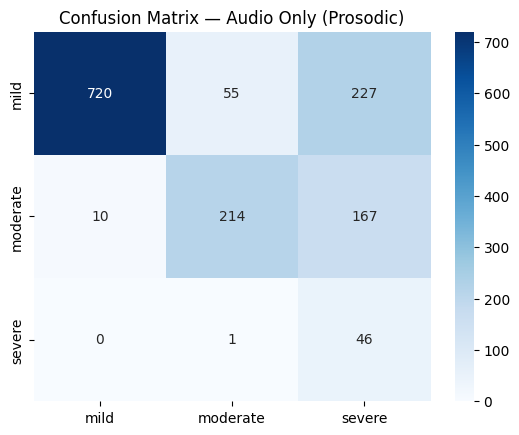

In [95]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        audio = batch["audio"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        logits = model(audio)
        y_pred.extend(torch.argmax(logits, 1).cpu().numpy())
        y_true.extend(labels.cpu().numpy())

print("\n===== FINAL TEST METRICS =====")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average="macro"))

print("\nCLASS REPORT")
print(classification_report(
    y_true, y_pred,
    target_names=[id2label[i] for i in range(len(id2label))],
    digits=4
))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=id2label.values(),
            yticklabels=id2label.values())
plt.title("Confusion Matrix — Audio Only (Prosodic)")
plt.show()
